In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd


In [5]:
df= pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
X = df.drop(columns='target',axis=1)
y = df['target']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state= 5)
log = LogisticRegression(solver = 'liblinear')
log.fit(X_train,y_train)

LogisticRegression(solver='liblinear')

In [8]:
y_pred = log.predict(X_test) 

In [9]:
# ROC Curve 
from sklearn.metrics import roc_curve,auc
#calculate probability scores of each data points
y_score = log.fit(X_train, y_train).decision_function(X_test)
#compute the ROC Curve values/FPR,TPR & threshhold
fpr, tpr, thresholds = roc_curve(y_test, y_score)


In [10]:
#area under the curve(AUC)
print(auc(fpr, tpr))

0.9397849462365592


AUC: 0.9397849462365592


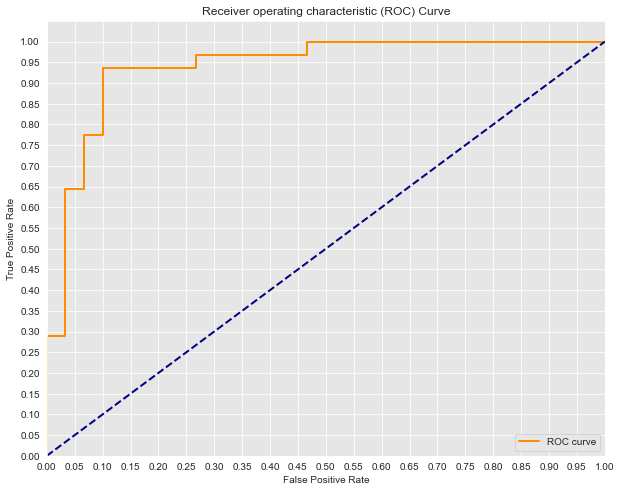

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Seaborn's beautiful styling
sns.set_style('darkgrid', {'axes.facecolor': '0.9'})

print('AUC: {}'.format(auc(fpr, tpr)))
plt.figure(figsize=(10, 8))
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.yticks([i/20.0 for i in range(21)])
plt.xticks([i/20.0 for i in range(21)])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Class imbalance 

In [12]:
#smot
! pip install imbalanced-learn

In [13]:
y.value_counts()

1    165
0    138
Name: target, dtype: int64

In [14]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=2)
X_s, y_s = smote.fit_resample(X,y)
y_s.value_counts()


1    165
0    165
Name: target, dtype: int64

In [16]:
df = pd.read_csv('tennis.csv')
df

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [17]:
df.shape

(14, 5)